In [319]:
# SHOPPING TRENDS - PROMO CODE PREDICTION
# FULL ML PIPELINE (EDA + TRAIN + EVAL + SAVE MODEL)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [320]:
# 1. LOAD DATA

df = pd.read_csv("data/shopping_trends_updated.csv")



In [321]:
# 2. CLEAN DATA (FIXED)
df = df.drop(columns=["Customer ID"], errors="ignore")


In [322]:
print(df.info())
print(df.head())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3900 non-null   int64  
 1   Gender                  3900 non-null   object 
 2   Item Purchased          3900 non-null   object 
 3   Category                3900 non-null   object 
 4   Purchase Amount (USD)   3900 non-null   int64  
 5   Location                3900 non-null   object 
 6   Size                    3900 non-null   object 
 7   Color                   3900 non-null   object 
 8   Season                  3900 non-null   object 
 9   Review Rating           3900 non-null   float64
 10  Subscription Status     3900 non-null   object 
 11  Shipping Type           3900 non-null   object 
 12  Discount Applied        3900 non-null   object 
 13  Promo Code Used         3900 non-null   object 
 14  Previous Purchases      3900 non-null   

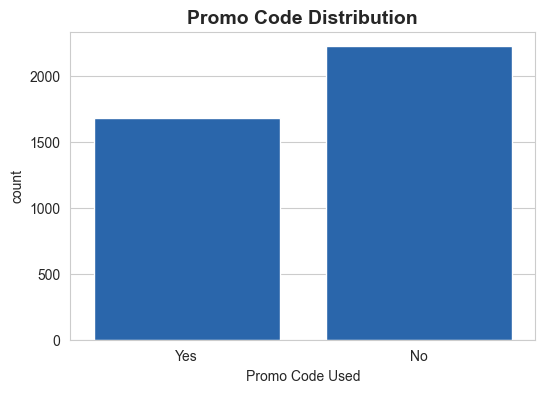

In [323]:
sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Promo Code Used",
    color="#1565C0"
)

plt.title("Promo Code Distribution", fontsize=14, fontweight="bold")

plt.show()

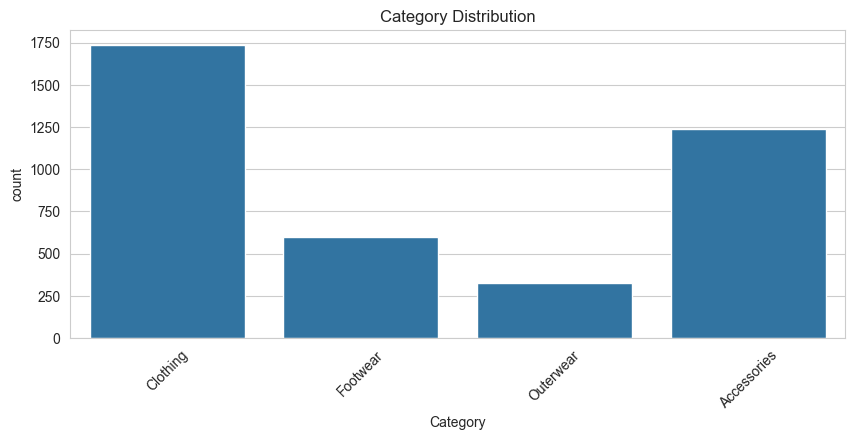

In [324]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Category")
plt.xticks(rotation=45)
plt.title("Category Distribution")
plt.show()


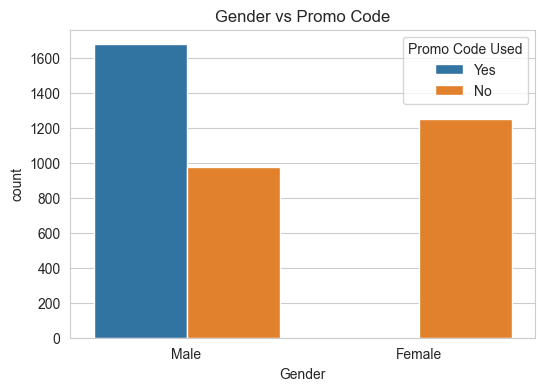

In [325]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Promo Code Used")
plt.title("Gender vs Promo Code")
plt.show()


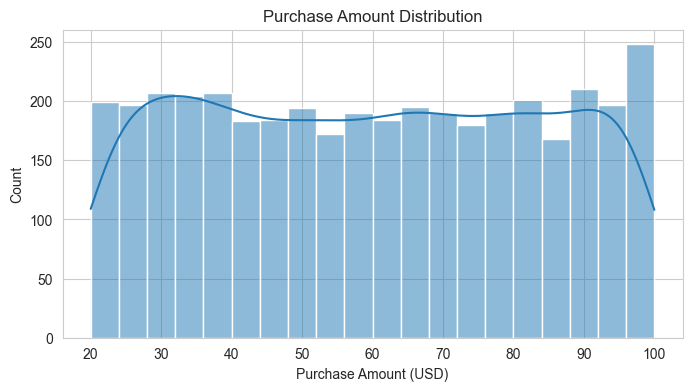

In [326]:
plt.figure(figsize=(8,4))
sns.histplot(df["Purchase Amount (USD)"], bins=20, kde=True)
plt.title("Purchase Amount Distribution")
plt.show()


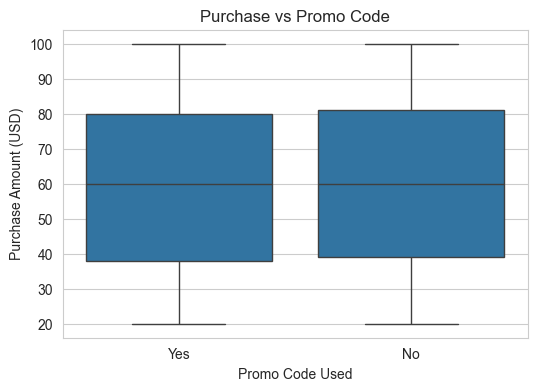

In [327]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Promo Code Used", y="Purchase Amount (USD)", data=df)
plt.title("Purchase vs Promo Code")
plt.show()


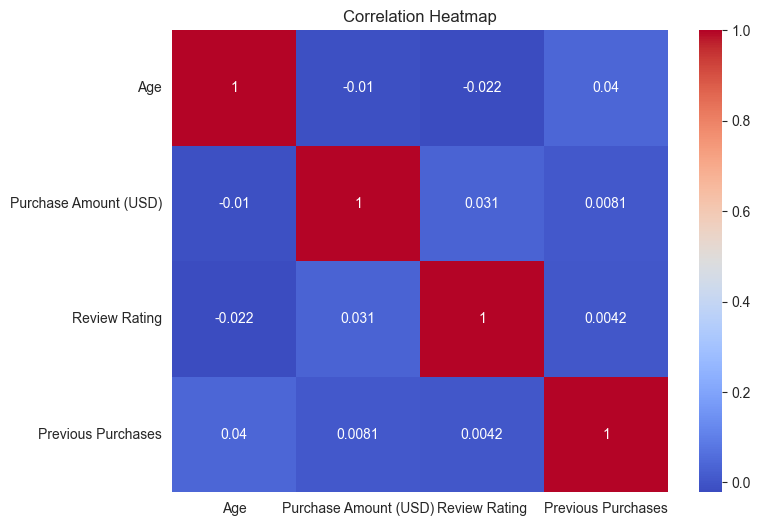

In [328]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [329]:
# 5. SPLIT FEATURES / TARGET
# =========================
y = df["Promo Code Used"]
X = df.drop(columns=["Promo Code Used"])

le = LabelEncoder()
y = le.fit_transform(y)


In [330]:
# 6. FEATURE ENGINEERING
# =========================
X["AgeGroup"] = pd.cut(
    X["Age"],
    bins=[18, 35, 55, 70, float("inf")],
    labels=["19-35", "36-55", "55-70", "71+"],
    right=False
).astype(str)


In [331]:
# 7. PREPROCESSING
# =========================
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns


In [332]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)


In [333]:
# 8. MODEL
# =========================
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])


In [334]:
# 10. TRAIN
model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [335]:
# 11. PREDICT
# =========================
y_pred = model.predict(X_test)


In [336]:
# 12. EVALUATION
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       422
           1       1.00      1.00      1.00       358

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



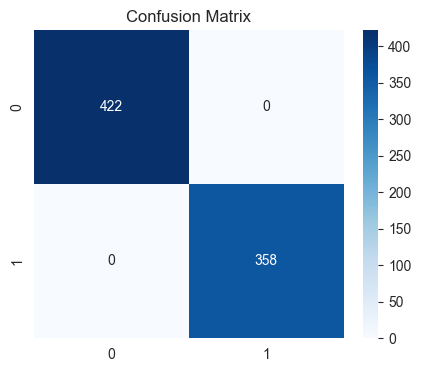

In [337]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [338]:
# 13. FEATURE IMPORTANCE (FIXED SAFE VERSION)

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["classifier"].feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)


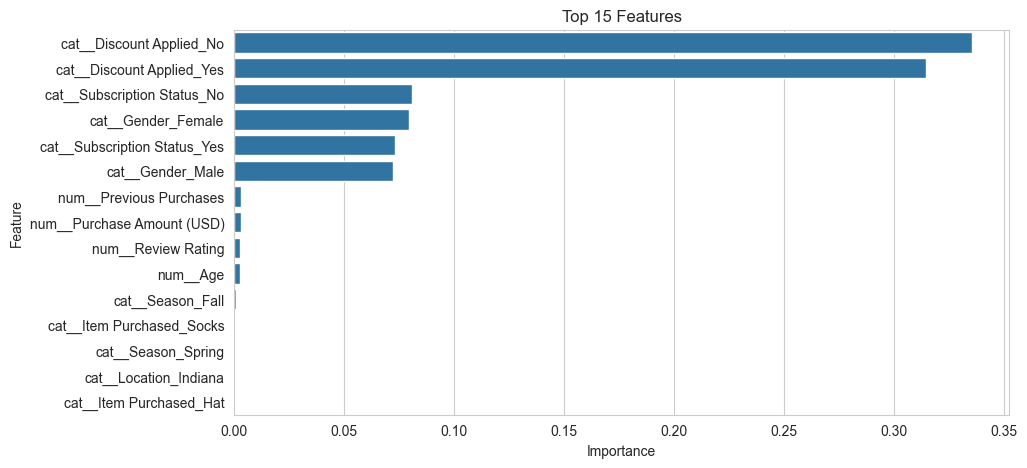

In [339]:
plt.figure(figsize=(10,5))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Top 15 Features")
plt.show()


In [ ]:
# 14. SAVE MODEL
# =========================
joblib.dump(model, "model/promo_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("MODEL SAVED SUCCESSFULLY")


plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Category")
plt.xticks(rotation=45)
plt.title("Category Distribution")
plt.show()
